## Imports

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import os
import sys
import matplotlib.pyplot as plt

#CHANGE AS NEEDED
sys.path.append('/home/patrick/ansermodelling')
os.chdir("/home/patrick/ansermodelling")


from models.FFNN_network import FFNN
from data.anser_dataset import AnserDataset
from models.train import train
from torch.utils.data import Subset


## Training with noise

In [2]:
### sigma = 0

In [3]:
def train_with_noise_plot(std):
    train_dataset = AnserDataset("data/dataset.npz", noise_std=std)
    test_dataset  = AnserDataset("data/dataset.npz", noise_std=0.0)
    
    n = len(train_dataset)
    n_train = int(0.8 * n)
    
    idx = np.random.permutation(n)
    train_idx, test_idx = idx[:n_train], idx[n_train:]
    
    
    train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=32, shuffle=True)
    test_loader  = DataLoader(Subset(test_dataset,  test_idx),  batch_size=32, shuffle=False)
    
    model = FFNN(input_dim=8, output_dim=5, hidden_dims=[64,256,64])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses, test_losses = train(model, train_loader, test_loader, optimizer, epochs=100, print_losses = True)

    fig, axes = plt.subplots(2,figsize=(10, 8))
    fig.suptitle(f'Noise std = {std}')
    axes[0].plot(train_losses)
    axes[0].set_title("train")
    axes[1].plot(test_losses)
    axes[1].set_title("test")
    plt.tight_layout()
    plt.show()

    


Epoch 0, train loss: 0.6694, test loss: 0.4997
Epoch 1, train loss: 0.4557, test loss: 0.4157
Epoch 2, train loss: 0.4030, test loss: 0.3830
Epoch 3, train loss: 0.3755, test loss: 0.3570
Epoch 4, train loss: 0.3568, test loss: 0.3681
Epoch 5, train loss: 0.3427, test loss: 0.3351
Epoch 6, train loss: 0.3315, test loss: 0.3246
Epoch 7, train loss: 0.3210, test loss: 0.3220
Epoch 8, train loss: 0.3137, test loss: 0.3259
Epoch 9, train loss: 0.3070, test loss: 0.3138
Epoch 10, train loss: 0.3013, test loss: 0.3053
Epoch 11, train loss: 0.2951, test loss: 0.3083
Epoch 12, train loss: 0.2905, test loss: 0.2943
Epoch 13, train loss: 0.2866, test loss: 0.2870
Epoch 14, train loss: 0.2828, test loss: 0.2838
Epoch 15, train loss: 0.2783, test loss: 0.2756
Epoch 16, train loss: 0.2737, test loss: 0.2879
Epoch 17, train loss: 0.2703, test loss: 0.2941
Epoch 18, train loss: 0.2673, test loss: 0.2889
Epoch 19, train loss: 0.2642, test loss: 0.2828
Epoch 20, train loss: 0.2606, test loss: 0.2726
Ep

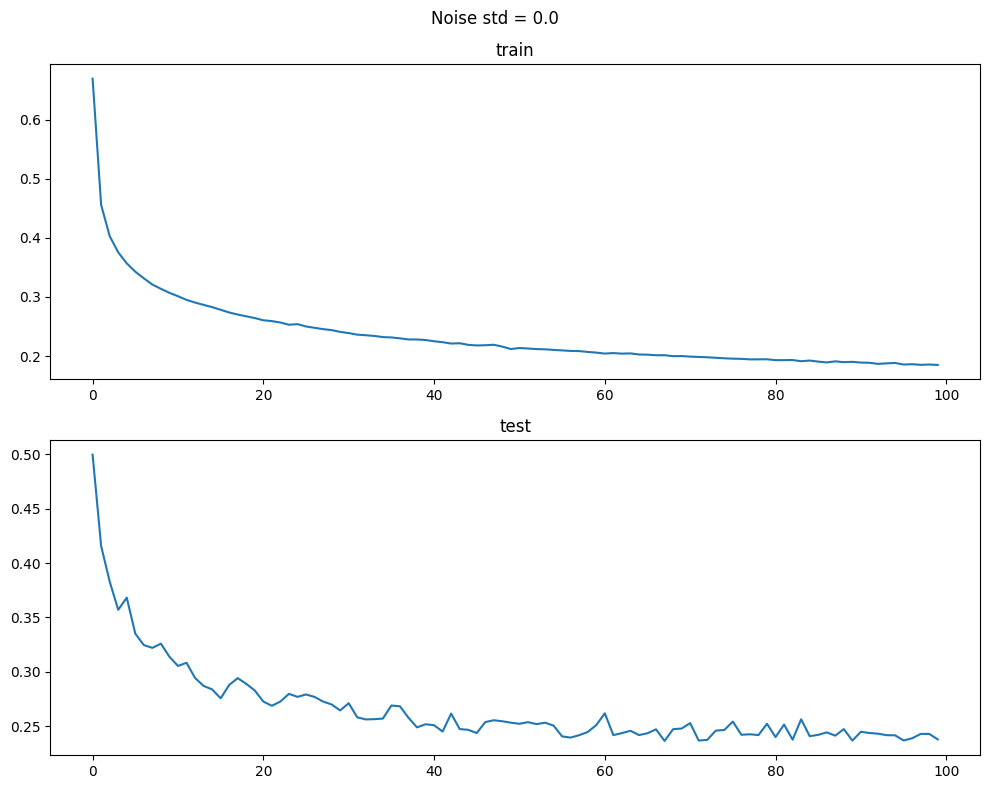

In [4]:
train_with_noise_plot(0.0)

Epoch 0, train loss: 0.6528, test loss: 0.4899
Epoch 1, train loss: 0.4463, test loss: 0.4164
Epoch 2, train loss: 0.4024, test loss: 0.3893
Epoch 3, train loss: 0.3768, test loss: 0.3668
Epoch 4, train loss: 0.3611, test loss: 0.3658
Epoch 5, train loss: 0.3500, test loss: 0.3561
Epoch 6, train loss: 0.3395, test loss: 0.3651
Epoch 7, train loss: 0.3337, test loss: 0.3273
Epoch 8, train loss: 0.3286, test loss: 0.3439
Epoch 9, train loss: 0.3214, test loss: 0.3200
Epoch 10, train loss: 0.3150, test loss: 0.3194
Epoch 11, train loss: 0.3120, test loss: 0.3187
Epoch 12, train loss: 0.3056, test loss: 0.3119
Epoch 13, train loss: 0.3041, test loss: 0.3089
Epoch 14, train loss: 0.2999, test loss: 0.3057
Epoch 15, train loss: 0.2964, test loss: 0.3130
Epoch 16, train loss: 0.2936, test loss: 0.3018
Epoch 17, train loss: 0.2894, test loss: 0.3034
Epoch 18, train loss: 0.2862, test loss: 0.2940
Epoch 19, train loss: 0.2856, test loss: 0.3111
Epoch 20, train loss: 0.2846, test loss: 0.2813
Ep

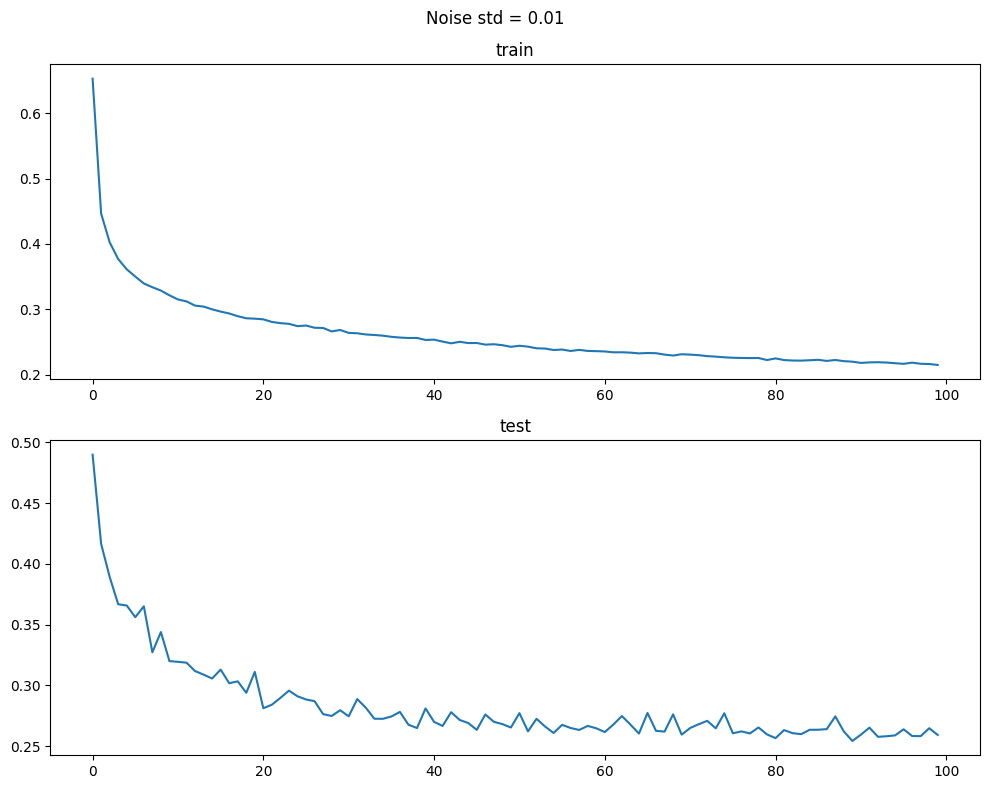

In [5]:
train_with_noise_plot(0.01)

In [6]:
'''
with old data
Epoch 95, train loss: 0.0063, test loss: 0.0068
Epoch 96, train loss: 0.0063, test loss: 0.0070
Epoch 97, train loss: 0.0062, test loss: 0.0068
Epoch 98, train loss: 0.0063, test loss: 0.0068
Epoch 99, train loss: 0.0063, test loss: 0.0070
'''

'\nwith old data\nEpoch 95, train loss: 0.0063, test loss: 0.0068\nEpoch 96, train loss: 0.0063, test loss: 0.0070\nEpoch 97, train loss: 0.0062, test loss: 0.0068\nEpoch 98, train loss: 0.0063, test loss: 0.0068\nEpoch 99, train loss: 0.0063, test loss: 0.0070\n'

Epoch 0, train loss: 0.6830, test loss: 0.5456
Epoch 1, train loss: 0.5334, test loss: 0.4740
Epoch 2, train loss: 0.5032, test loss: 0.4503
Epoch 3, train loss: 0.4858, test loss: 0.4462
Epoch 4, train loss: 0.4792, test loss: 0.4402
Epoch 5, train loss: 0.4704, test loss: 0.4348
Epoch 6, train loss: 0.4658, test loss: 0.4197
Epoch 7, train loss: 0.4582, test loss: 0.4223
Epoch 8, train loss: 0.4551, test loss: 0.4277
Epoch 9, train loss: 0.4556, test loss: 0.4179
Epoch 10, train loss: 0.4503, test loss: 0.3982
Epoch 11, train loss: 0.4489, test loss: 0.4200
Epoch 12, train loss: 0.4473, test loss: 0.4275
Epoch 13, train loss: 0.4449, test loss: 0.3965
Epoch 14, train loss: 0.4431, test loss: 0.4088
Epoch 15, train loss: 0.4441, test loss: 0.4012
Epoch 16, train loss: 0.4404, test loss: 0.4028
Epoch 17, train loss: 0.4384, test loss: 0.3865
Epoch 18, train loss: 0.4380, test loss: 0.4057
Epoch 19, train loss: 0.4375, test loss: 0.3936
Epoch 20, train loss: 0.4349, test loss: 0.4036
Ep

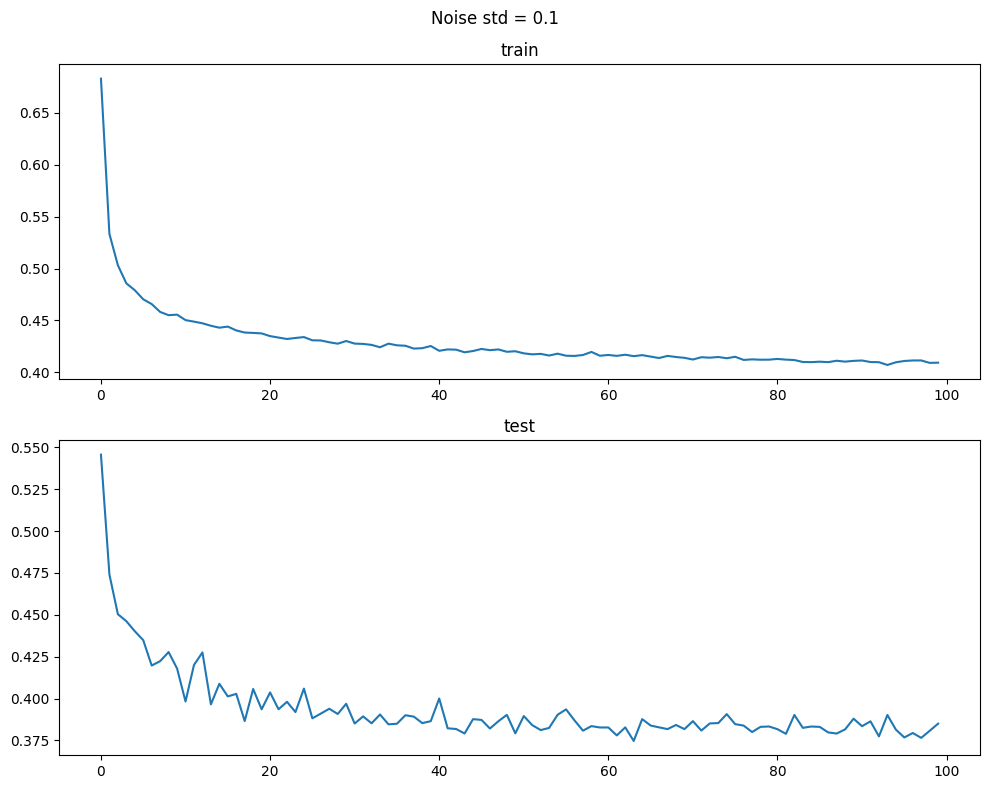

In [7]:
train_with_noise_plot(0.1)

Epoch 0, train loss: 0.7927, test loss: 0.7271
Epoch 1, train loss: 0.7437, test loss: 0.7008
Epoch 2, train loss: 0.7355, test loss: 0.7015
Epoch 3, train loss: 0.7319, test loss: 0.6975
Epoch 4, train loss: 0.7282, test loss: 0.6950
Epoch 5, train loss: 0.7291, test loss: 0.6831
Epoch 6, train loss: 0.7252, test loss: 0.6857
Epoch 7, train loss: 0.7270, test loss: 0.6825
Epoch 8, train loss: 0.7251, test loss: 0.6863
Epoch 9, train loss: 0.7247, test loss: 0.6816
Epoch 10, train loss: 0.7229, test loss: 0.6895
Epoch 11, train loss: 0.7249, test loss: 0.6812
Epoch 12, train loss: 0.7230, test loss: 0.6804
Epoch 13, train loss: 0.7226, test loss: 0.6777
Epoch 14, train loss: 0.7213, test loss: 0.6824
Epoch 15, train loss: 0.7207, test loss: 0.6938
Epoch 16, train loss: 0.7219, test loss: 0.6867
Epoch 17, train loss: 0.7214, test loss: 0.6797
Epoch 18, train loss: 0.7193, test loss: 0.6849
Epoch 19, train loss: 0.7194, test loss: 0.6694
Epoch 20, train loss: 0.7194, test loss: 0.6917
Ep

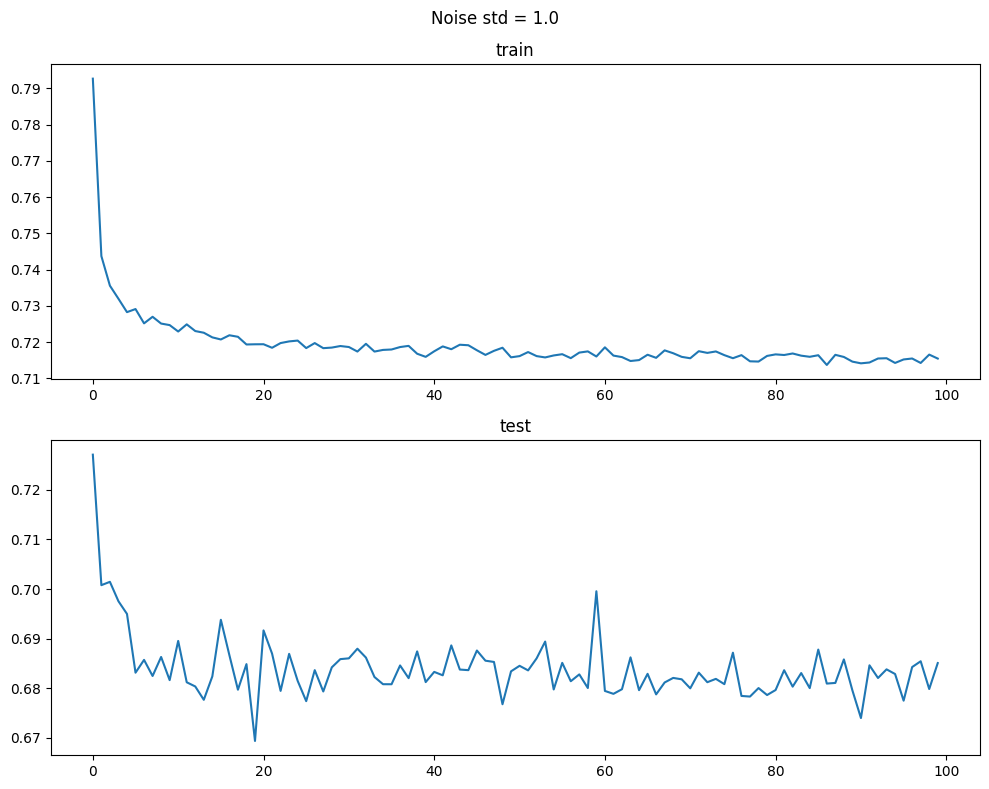

In [8]:
train_with_noise_plot(1.0)

Epoch 0, train loss: 0.8599, test loss: 0.8277
Epoch 1, train loss: 0.8287, test loss: 0.8171
Epoch 2, train loss: 0.8285, test loss: 0.8177
Epoch 3, train loss: 0.8271, test loss: 0.8124
Epoch 4, train loss: 0.8267, test loss: 0.8183
Epoch 5, train loss: 0.8271, test loss: 0.8169
Epoch 6, train loss: 0.8269, test loss: 0.8120
Epoch 7, train loss: 0.8268, test loss: 0.8105
Epoch 8, train loss: 0.8269, test loss: 0.8195
Epoch 9, train loss: 0.8268, test loss: 0.8153
Epoch 10, train loss: 0.8269, test loss: 0.8173
Epoch 11, train loss: 0.8270, test loss: 0.8234
Epoch 12, train loss: 0.8272, test loss: 0.8170
Epoch 13, train loss: 0.8270, test loss: 0.8215
Epoch 14, train loss: 0.8269, test loss: 0.8363
Epoch 15, train loss: 0.8269, test loss: 0.8170
Epoch 16, train loss: 0.8267, test loss: 0.8224
Epoch 17, train loss: 0.8268, test loss: 0.8194
Epoch 18, train loss: 0.8270, test loss: 0.8145
Epoch 19, train loss: 0.8270, test loss: 0.8208
Epoch 20, train loss: 0.8266, test loss: 0.8188
Ep

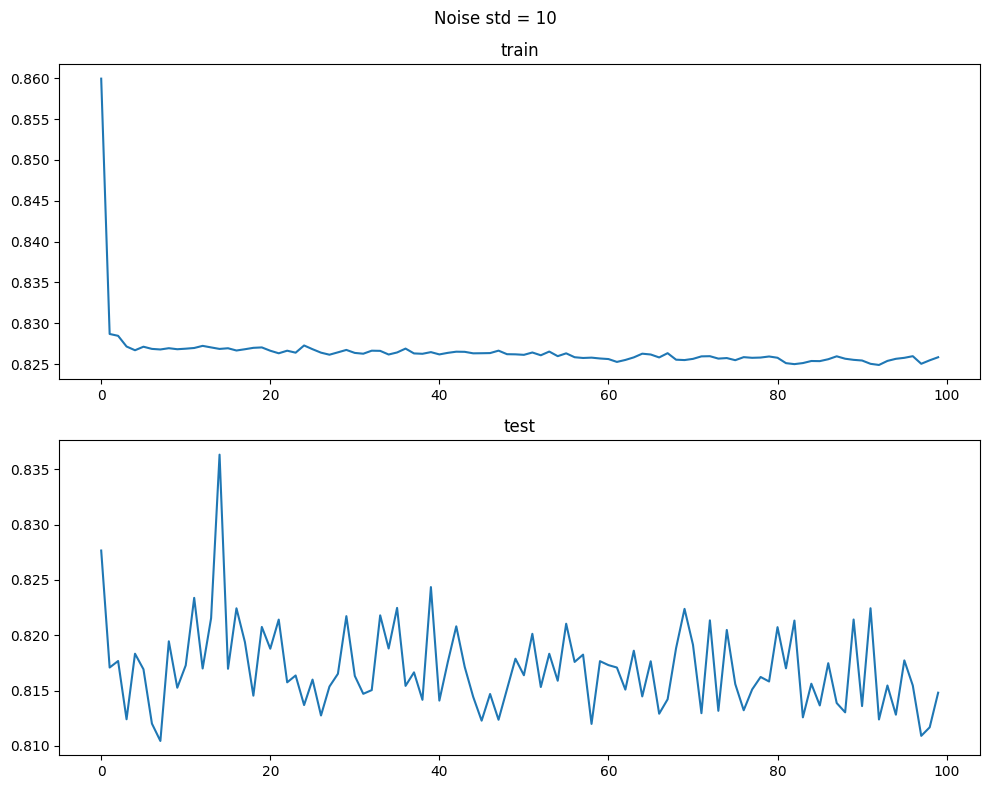

In [9]:
train_with_noise_plot(10)